# 04. Thí nghiệm với các phương pháp bậc hai

Phương pháp Newton, biến thể damped, biến thể giải hệ bằng conjugate gradient,
và L-BFGS.

Với hàm mục tiêu bậc hai, bước Newton đầy đủ đưa nghiệm về đúng `w*` sau một vòng
lặp. Vì vậy điều đáng so sánh không phải số vòng lặp, mà là chi phí thời gian của
một vòng lặp Newton so với thời gian các phương pháp bậc một cần để đạt cùng độ
chính xác.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.plotting import set_style

set_style()


In [2]:
from src.data import load_problem
from src.plotting import plot_comparison, summary_table
from src.runner import newton_grid, run_or_load

problem, config = load_problem()
print(f"n = {problem.n}, d = {problem.d}, kappa = {problem.kappa:.6g}")

n = 160000, d = 280, kappa = 268.309


## F. Các biến thể Newton

[1/5] Newton ($t = 1$, refactor each iteration)     status=converged  gap=0.000e+00 time=0.1359s


[2/5] Newton ($t = 1$, cached factor)               status=converged  gap=0.000e+00 time=0.1330s


[3/5] Newton (damped, backtracking)                 status=converged  gap=0.000e+00 time=0.1683s


[4/5] Newton-CG (cg_tol $= 10^{-2}$)                status=converged  gap=-3.469e-18 time=1.3237s


[5/5] Newton-CG (cg_tol $= 10^{-6}$)                status=converged  gap=3.469e-18 time=1.2759s
[done] newton: 5 runs written to newton.json


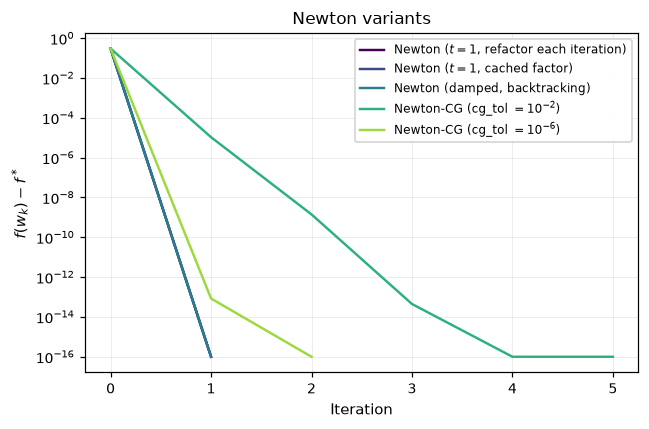

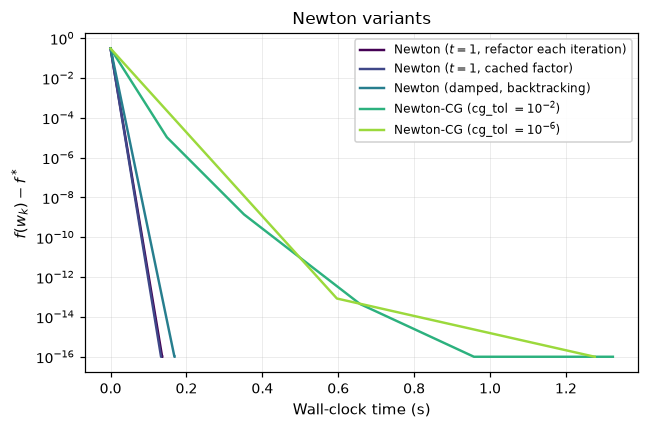

In [3]:
newton_runs = run_or_load(problem, "newton", newton_grid(problem), repeats=3, extra=config)

plot_comparison(newton_runs, problem.f_star, stem="newton", title="Newton variants")
plt.show()

In [4]:
summary_table(newton_runs, problem.f_star)

,method,setup,status,iters_to_1e-06,time_to_1e-06_s,final_f,final_gap,final_grad_norm,total_time_s,n_f_evals,n_grad_evals,n_sample_grads
0,newton,"Newton ($t = 1$, refactor each iteration)",converged,1,0.135851,0.023743,0.000000e+00,5.617266e-15,0.135868,2,2,480000
1,newton,"Newton ($t = 1$, cached factor)",converged,1,0.132985,0.023743,0.000000e+00,5.617266e-15,0.132999,2,2,480000
2,newton,"Newton (damped, backtracking)",converged,1,0.168256,0.023743,0.000000e+00,5.617266e-15,0.168273,3,2,640000
3,newton_cg,Newton-CG (cg_tol $= 10^{-2}$),converged,2,0.351560,0.023743,-3.469447e-18,9.739533e-12,1.323743,6,6,8800000
4,newton_cg,Newton-CG (cg_tol $= 10^{-6}$),converged,1,0.596442,0.023743,3.469447e-18,1.583053e-13,1.275850,3,3,8000000


## Kiểm chứng: bước Newton trùng với nghiệm đóng

Với `w_0 = 0`, một bước Newton cho đúng `w*`. Đây là hệ quả trực tiếp của việc
Hessian không phụ thuộc `w`.

In [5]:
from src.second_order import newton

one_step = newton(problem, max_iter=1, tol=0.0)
print("khoảng cách tới nghiệm đóng:", np.linalg.norm(one_step.w_final - problem.w_star))
print("sai số hàm mục tiêu       :", one_step.f_final - problem.f_star)

khoảng cách tới nghiệm đóng: 0.0
sai số hàm mục tiêu       : 0.0


## L-BFGS

[1/4] L-BFGS ($m = 3$)                              status=stalled    gap=6.592e-17 time=1.9649s


[2/4] L-BFGS ($m = 5$)                              status=stalled    gap=4.163e-17 time=1.7253s


[3/4] L-BFGS ($m = 10$)                             status=stalled    gap=1.388e-17 time=1.3788s


[4/4] L-BFGS ($m = 20$)                             status=stalled    gap=0.000e+00 time=1.4920s
[done] lbfgs: 4 runs written to lbfgs.json


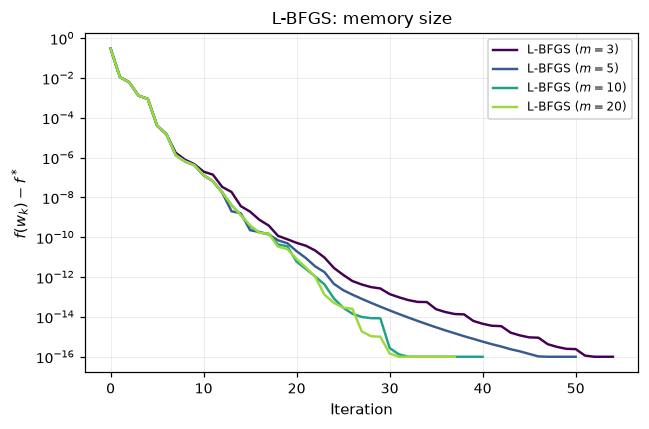

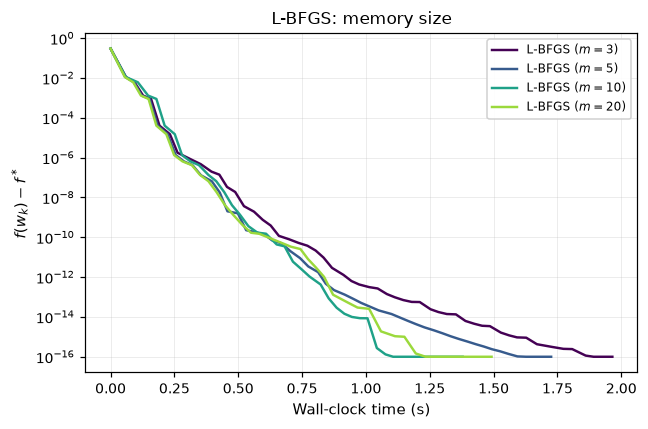

In [6]:
specs = [
    {
        "method": "lbfgs",
        "kwargs": {"max_iter": 60, "memory": m},
        "label": rf"L-BFGS ($m = {m}$)",
    }
    for m in (3, 5, 10, 20)
]
lbfgs_runs = run_or_load(problem, "lbfgs", specs, repeats=3, extra=config)

plot_comparison(lbfgs_runs, problem.f_star, stem="lbfgs", title="L-BFGS: memory size")
plt.show()

## Chi phí mỗi vòng lặp

Bảng dưới đối chiếu chi phí lý thuyết mỗi vòng lặp với thời gian đo được, để thấy
vì sao Newton thắng về số vòng lặp nhưng không nhất thiết thắng về thời gian.

In [7]:
rows = []
for res in newton_runs + lbfgs_runs:
    rows.append(
        {
            "method": res.params["label"],
            "n_iter": res.n_iter,
            "total_time_s": res.total_time,
            "time_per_iter_ms": 1e3 * res.total_time / max(res.n_iter, 1),
            "final_gap": res.f_final - problem.f_star,
        }
    )
pd.DataFrame(rows)

,method,n_iter,total_time_s,time_per_iter_ms,final_gap
0,"Newton ($t = 1$, refactor each iteration)",1,0.135868,135.868020,0.000000e+00
1,"Newton ($t = 1$, cached factor)",1,0.132999,132.999109,0.000000e+00
2,"Newton (damped, backtracking)",1,0.168273,168.272788,0.000000e+00
3,Newton-CG (cg_tol $= 10^{-2}$),5,1.323743,264.748542,-3.469447e-18
4,Newton-CG (cg_tol $= 10^{-6}$),2,1.275850,637.925035,3.469447e-18
5,L-BFGS ($m = 3$),54,1.964947,36.387907,6.591949e-17
6,L-BFGS ($m = 5$),50,1.725269,34.505382,4.163336e-17
7,L-BFGS ($m = 10$),40,1.378773,34.469323,1.387779e-17
8,L-BFGS ($m = 20$),37,1.492005,40.324465,0.000000e+00
